### Exploratory Data Analysis — Human Stress Detection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/raw/extended_stress_detection_data.csv")
df = pd.read_csv(DATA_PATH)

target = "Stress_Detection"
class_counts = df[target].value_counts()
class_percentages = df[target].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(target_summary)



,Count,Percentage
Stress_Detection,,
Medium,1258,41.93
High,1118,37.27
Low,624,20.80


## EDA: Class Imbalance Analysis

,Count,Percentage,Relative_to_Minority
Stress_Detection,,,
Medium,1258,41.93,2.02
High,1118,37.27,1.79
Low,624,20.80,1.00


Majority class      : Medium (1258 samples)
Minority class      : Low (624 samples)
Majority/Minority   : 2.02:1


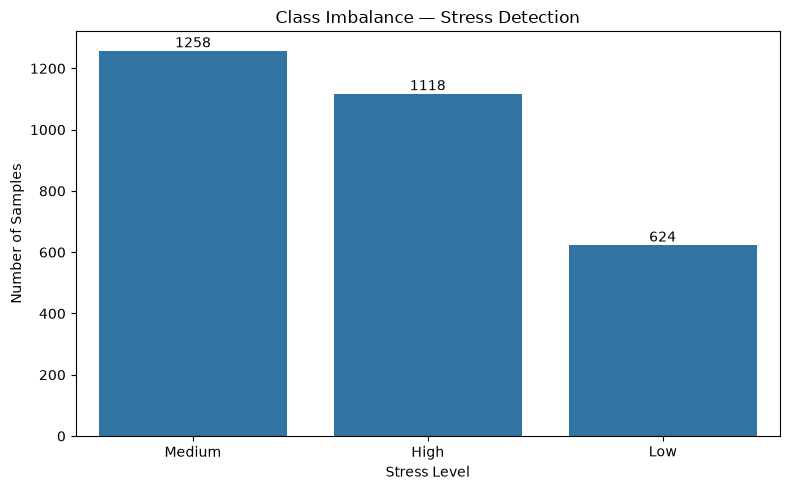

In [4]:
class_counts = df[target].value_counts()
majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(df) * 100).round(2),
    "Relative_to_Minority": (class_counts / minority_count).round(2)
})

display(class_balance)

print(f"Majority class      : {class_counts.idxmax()} ({majority_count} samples)")
print(f"Minority class      : {class_counts.idxmin()} ({minority_count} samples)")
print(f"Majority/Minority   : {imbalance_ratio:.2f}:1")

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Imbalance — Stress Detection")
plt.xlabel("Stress Level")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## EDA : Custom Sign Filled

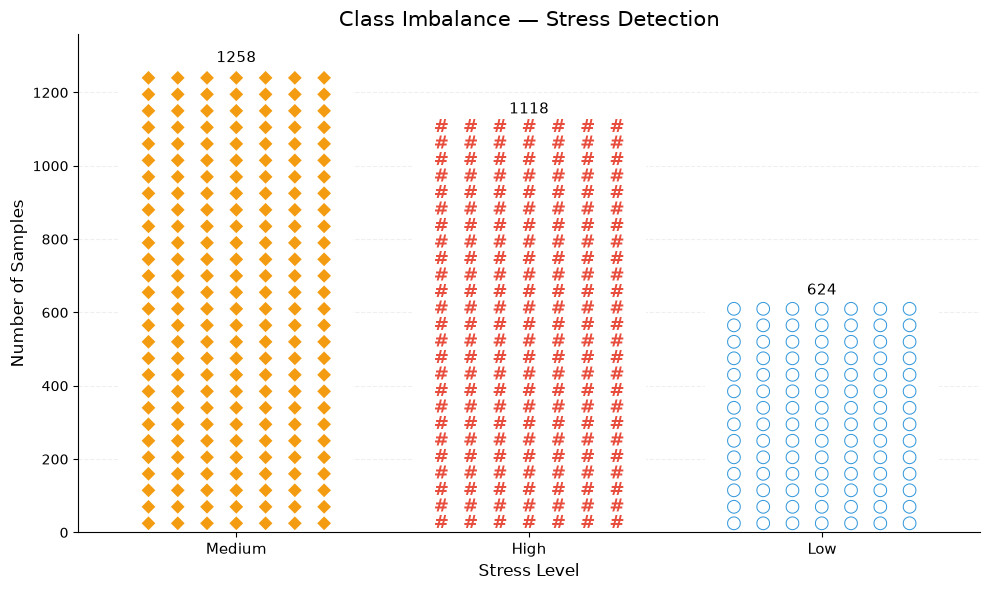

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class_counts = df[target].value_counts()

labels = ["Medium", "High", "Low"]
counts = [int(class_counts[label]) for label in labels]

styles = {
    "Medium": {"sign": "◆", "color": "#F39C12"},
    "High": {"sign": "#", "color": "#E74C3C"},
    "Low": {"sign": "○", "color": "#3498DB"}
}

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(labels))
bar_width = 0.8

bars = ax.bar(
    x_positions,
    counts,
    width=bar_width,
    color="white",
    edgecolor="none",
    linewidth=0,
    zorder=1
)

for i, label in enumerate(labels):

    count = counts[i]
    sign = styles[label]["sign"]
    color = styles[label]["color"]

    bar_left = x_positions[i] - bar_width / 2
    bar_right = x_positions[i] + bar_width / 2

    cols = 7
    x_spacing = bar_width / (cols + 1)

    y_spacing = 45

    for row, y in enumerate(np.arange(25, count, y_spacing)):

        for col in range(cols):

            x = bar_left + (col + 1) * x_spacing

            txt = ax.text(
                x,
                y,
                sign,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color,
                zorder=2
            )

            clip = Rectangle(
                (bar_left, 0),
                bar_width,
                count,
                transform=ax.transData
            )

            txt.set_clip_path(clip)

    ax.text(
        x_positions[i],
        count + 15,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylabel(
    "Number of Samples",
    fontsize=12
)

ax.set_xlabel(
    "Stress Level",
    fontsize=12
)

ax.set_title(
    "Class Imbalance — Stress Detection",
    fontsize=15
)

ax.set_ylim(0, max(counts) * 1.08)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2,
    zorder=0
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# EDA : Target Class Distribution

Stress_Detection
Medium    1258
High      1118
Low        624
Name: count, dtype: int64

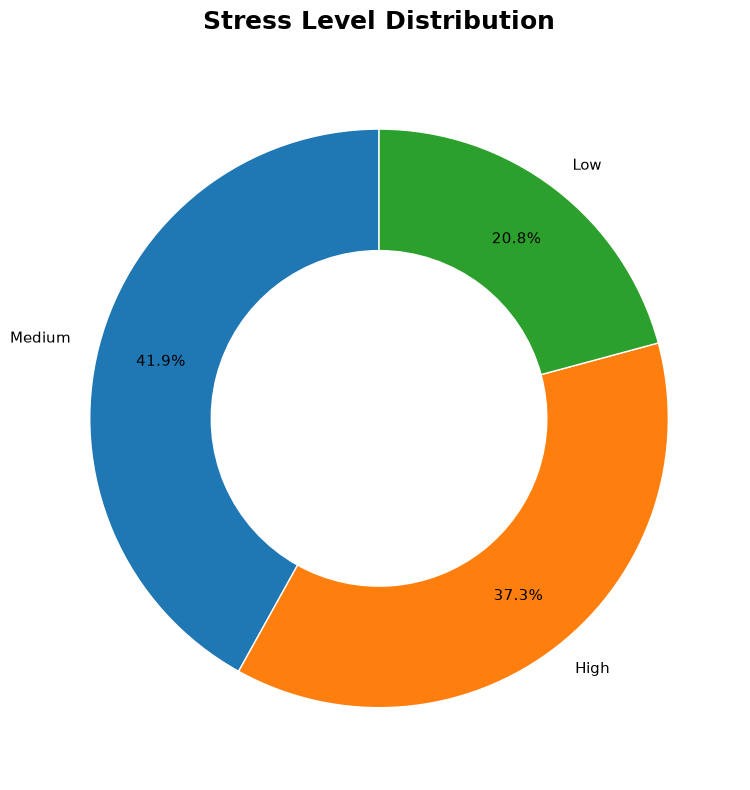

In [ ]:

stress_counts = df["Stress_Detection"].value_counts()

display(stress_counts)


# ------------------------------------------------------------
# Donut Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.pie(
    stress_counts,
    labels=stress_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 11
    }
)

plt.title(
    "Stress Level Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

## EDA : Age Distribution

Age Group Statistics:


,Samples,Percentage
Age,,
Young (18–29),297,9.90
Adult (30–39),1265,42.17
Middle-aged (40–49),1115,37.17
Older (50+),323,10.77


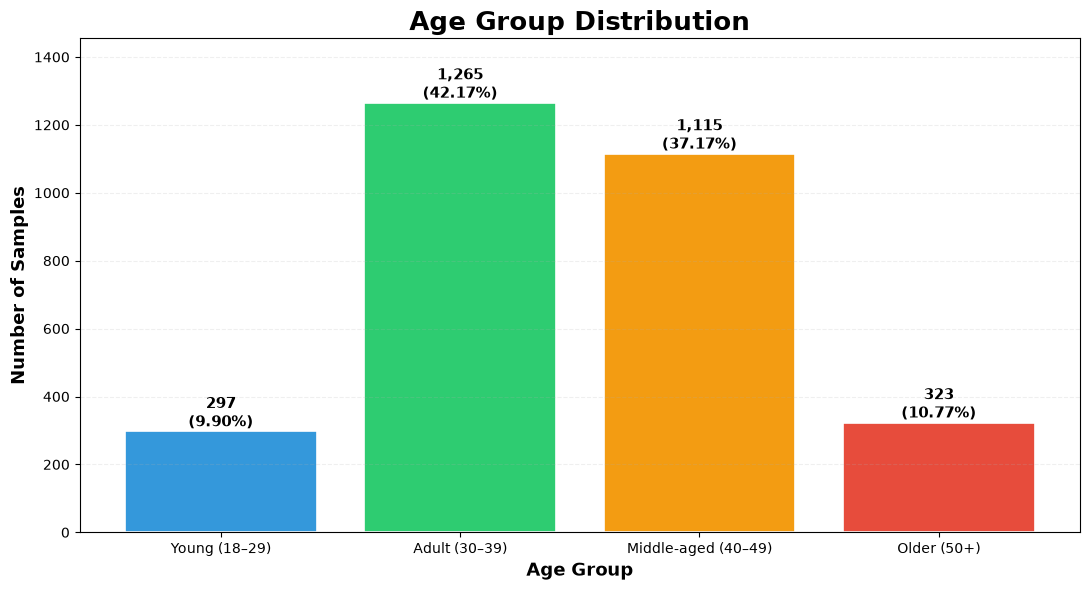

In [19]:
# EDA : Age Group Distribution

age_groups = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["Young (18–29)", "Adult (30–39)", "Middle-aged (40–49)", "Older (50+)"]
)

age_summary = (
    age_groups.value_counts()
    .sort_index()
    .to_frame("Samples")
)

age_summary["Percentage"] = (
    age_summary["Samples"] / len(df) * 100
).round(2)

# Display statistics
print("Age Group Statistics:")
display(age_summary)

# Plot
colors = ["#3498DB", "#2ECC71", "#F39C12", "#E74C3C"]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    age_summary.index,
    age_summary["Samples"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

for bar, count, percentage in zip(
    bars,
    age_summary["Samples"],
    age_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Age Group Distribution", fontsize=19, fontweight="bold")
plt.xlabel("Age Group", fontsize=13, fontweight="bold")
plt.ylabel("Number of Samples", fontsize=13, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.ylim(0, age_summary["Samples"].max() * 1.15)

plt.tight_layout()
plt.show()

Age Group Statistics:


,Samples,Percentage
Age,,
Young (18–29),297,9.90
Adult (30–39),1265,42.17
Middle-aged (40–49),1115,37.17
Older (50+),323,10.77


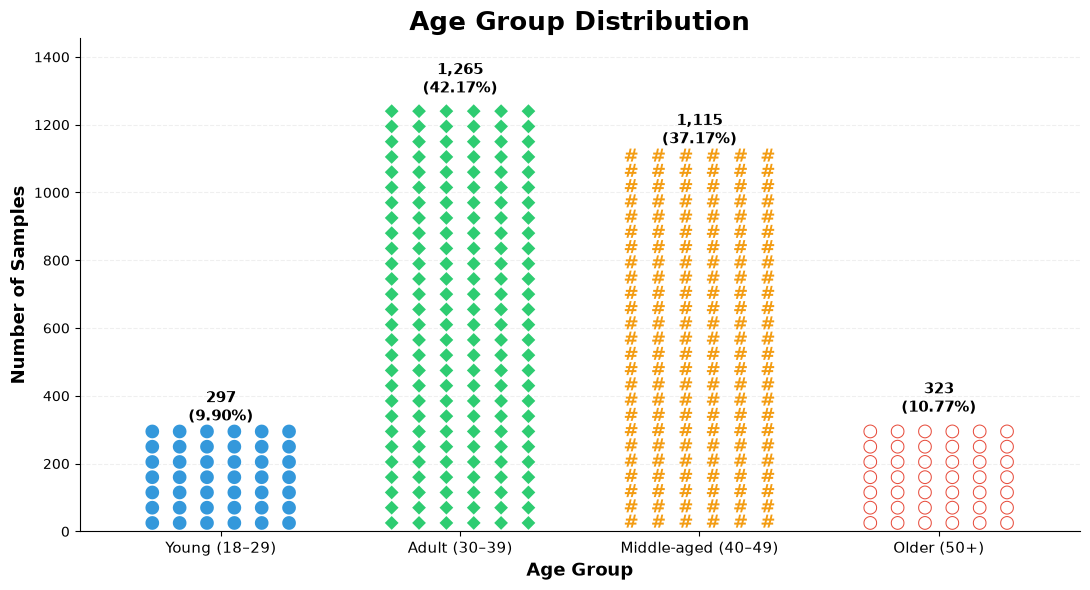

In [70]:
age_groups = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["Young (18–29)", "Adult (30–39)", "Middle-aged (40–49)", "Older (50+)"]
)

age_summary = (
    age_groups.value_counts()
    .sort_index()
    .to_frame("Samples")
)

age_summary["Percentage"] = (
    age_summary["Samples"] / len(df) * 100
).round(2)

print("Age Group Statistics:")
display(age_summary)

styles = {
    "Young (18–29)": {"sign": "●", "color": "#3498DB"},
    "Adult (30–39)": {"sign": "◆", "color": "#2ECC71"},
    "Middle-aged (40–49)": {"sign": "#", "color": "#F39C12"},
    "Older (50+)": {"sign": "○", "color": "#E74C3C"}
}

labels = list(age_summary.index)
counts = age_summary["Samples"].tolist()
percentages = age_summary["Percentage"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(labels))
bar_width = 0.8

ax.bar(
    x_positions,
    counts,
    width=bar_width,
    color="white",
    edgecolor="none",
    linewidth=0,
    zorder=1
)

for i, label in enumerate(labels):

    count = counts[i]
    sign = styles[label]["sign"]
    color = styles[label]["color"]

    bar_left = x_positions[i] - bar_width / 2

    cols = 6
    x_spacing = bar_width / (cols + 1)
    y_spacing = 45

    for y in np.arange(25, count, y_spacing):

        for col in range(cols):

            x = bar_left + (col + 1) * x_spacing

            txt = ax.text(
                x,
                y,
                sign,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color,
                zorder=2
            )

            clip = Rectangle(
                (bar_left, 0),
                bar_width,
                count,
                transform=ax.transData
            )

            txt.set_clip_path(clip)

    ax.text(
        x_positions[i],
        count + 15,
        f"{count:,}\n({percentages[i]:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, fontsize=11)

ax.set_title(
    "Age Group Distribution",
    fontsize=19,
    fontweight="bold"
)

ax.set_xlabel(
    "Age Group",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Samples",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylim(0, age_summary["Samples"].max() * 1.15)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,Statistic,Value
0,Count,3000.00
1,Mean,38.85
2,Median,38.74
3,Standard Deviation,7.59
4,Variance,57.56
5,Minimum,16.98
6,Q1 (25%),33.10
7,Q3 (75%),44.47
8,Maximum,60.84
9,Range,43.86


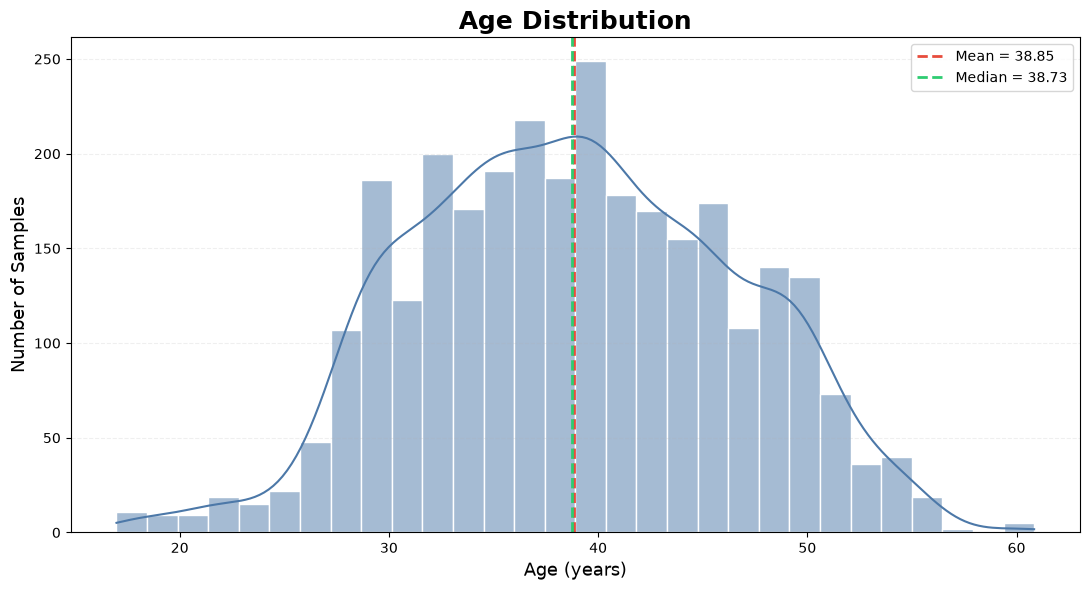

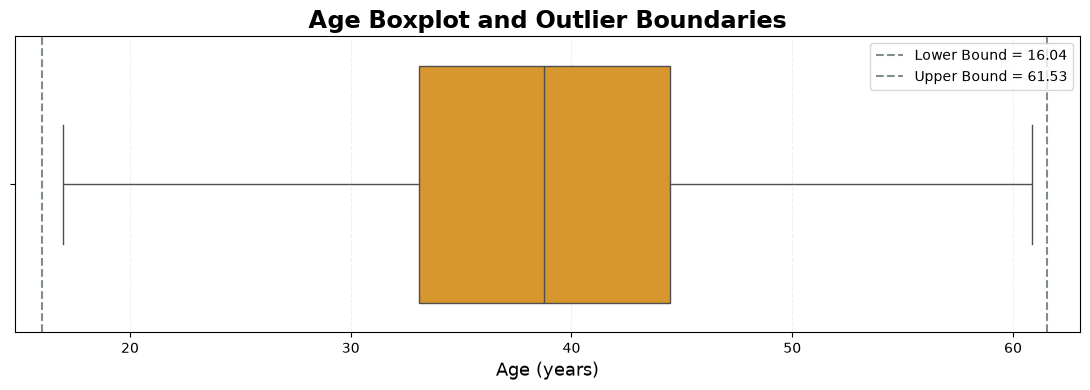

In [21]:
# EDA : Age - Statistical Analysis + Visualization

age = df["Age"].dropna()

# ---------- Statistics ----------
q1 = age.quantile(0.25)
q3 = age.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = age[(age < lower_bound) | (age > upper_bound)]

age_statistics = pd.DataFrame({
    "Statistic": [
        "Count", "Mean", "Median", "Standard Deviation", "Variance",
        "Minimum", "Q1 (25%)", "Q3 (75%)", "Maximum", "Range", "IQR",
        "Skewness", "Kurtosis", "Lower Outlier Bound",
        "Upper Outlier Bound", "Number of Outliers", "Outlier Percentage"
    ],
    "Value": [
        len(age), age.mean(), age.median(), age.std(), age.var(),
        age.min(), q1, q3, age.max(), age.max() - age.min(), iqr,
        age.skew(), age.kurtosis(), lower_bound, upper_bound,
        len(outliers), len(outliers) / len(age) * 100
    ]
})

age_statistics["Value"] = age_statistics["Value"].round(2)

display(age_statistics)


# ---------- Visualization 1: Distribution ----------
plt.figure(figsize=(11, 6))

sns.histplot(
    age,
    bins=30,
    kde=True,
    color="#4C78A8",
    edgecolor="white"
)

plt.axvline(
    age.mean(),
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {age.mean():.2f}"
)

plt.axvline(
    age.median(),
    color="#2ECC71",
    linestyle="--",
    linewidth=2,
    label=f"Median = {age.median():.2f}"
)

plt.title("Age Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Age (years)", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()


# ---------- Visualization 2: Boxplot & Outliers ----------
plt.figure(figsize=(11, 4))

sns.boxplot(
    x=age,
    color="#F39C12",
    flierprops={
        "marker": "o",
        "markerfacecolor": "#E74C3C",
        "markersize": 6
    }
)

plt.axvline(
    lower_bound,
    color="#7F8C8D",
    linestyle="--",
    label=f"Lower Bound = {lower_bound:.2f}"
)

plt.axvline(
    upper_bound,
    color="#7F8C8D",
    linestyle="--",
    label=f"Upper Bound = {upper_bound:.2f}"
)

plt.title("Age Boxplot and Outlier Boundaries", fontsize=17, fontweight="bold")
plt.xlabel("Age (years)", fontsize=13)
plt.legend()

plt.grid(axis="x", linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

### EDA : Distribution of Important Numerical Features

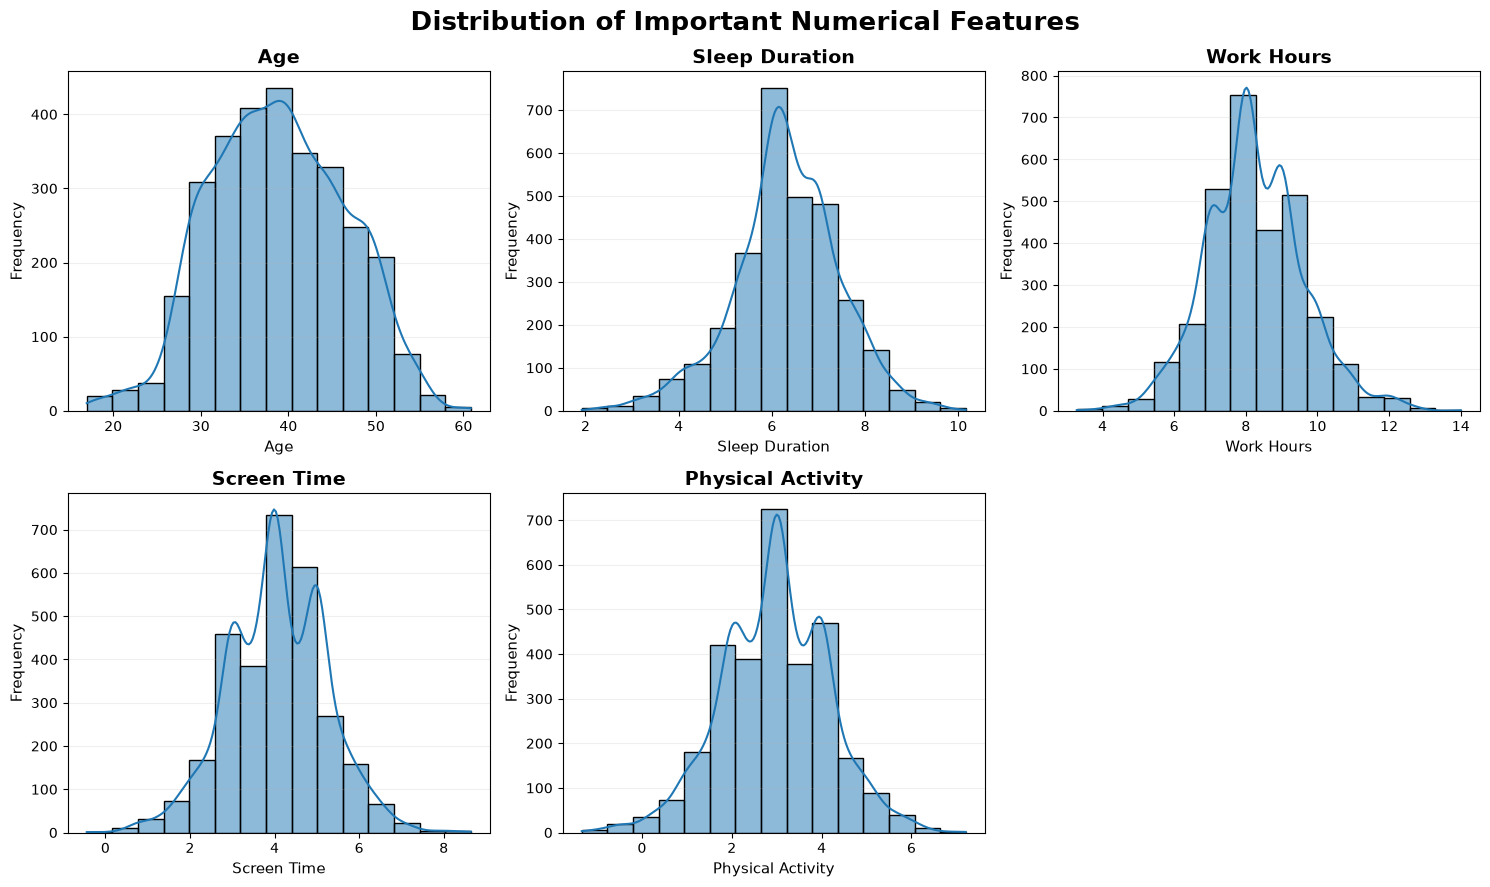

In [78]:

important_numeric = [
    "Age",
    "Sleep_Duration",
    "Work_Hours",
    "Screen_Time",
    "Physical_Activity"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, col in enumerate(important_numeric):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=15,
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace("_", " "),
        fontsize=14,
        fontweight="bold"
    )

    axes[i].set_xlabel(
        col.replace("_", " "),
        fontsize=11
    )

    axes[i].set_ylabel(
        "Frequency",
        fontsize=11
    )

    axes[i].grid(
        axis="y",
        alpha=0.2
    )

# Remove unused subplot
for j in range(len(important_numeric), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Important Numerical Features",
    fontsize=19,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# EDA : Custom Sign-Filled Histogram of important numerical 

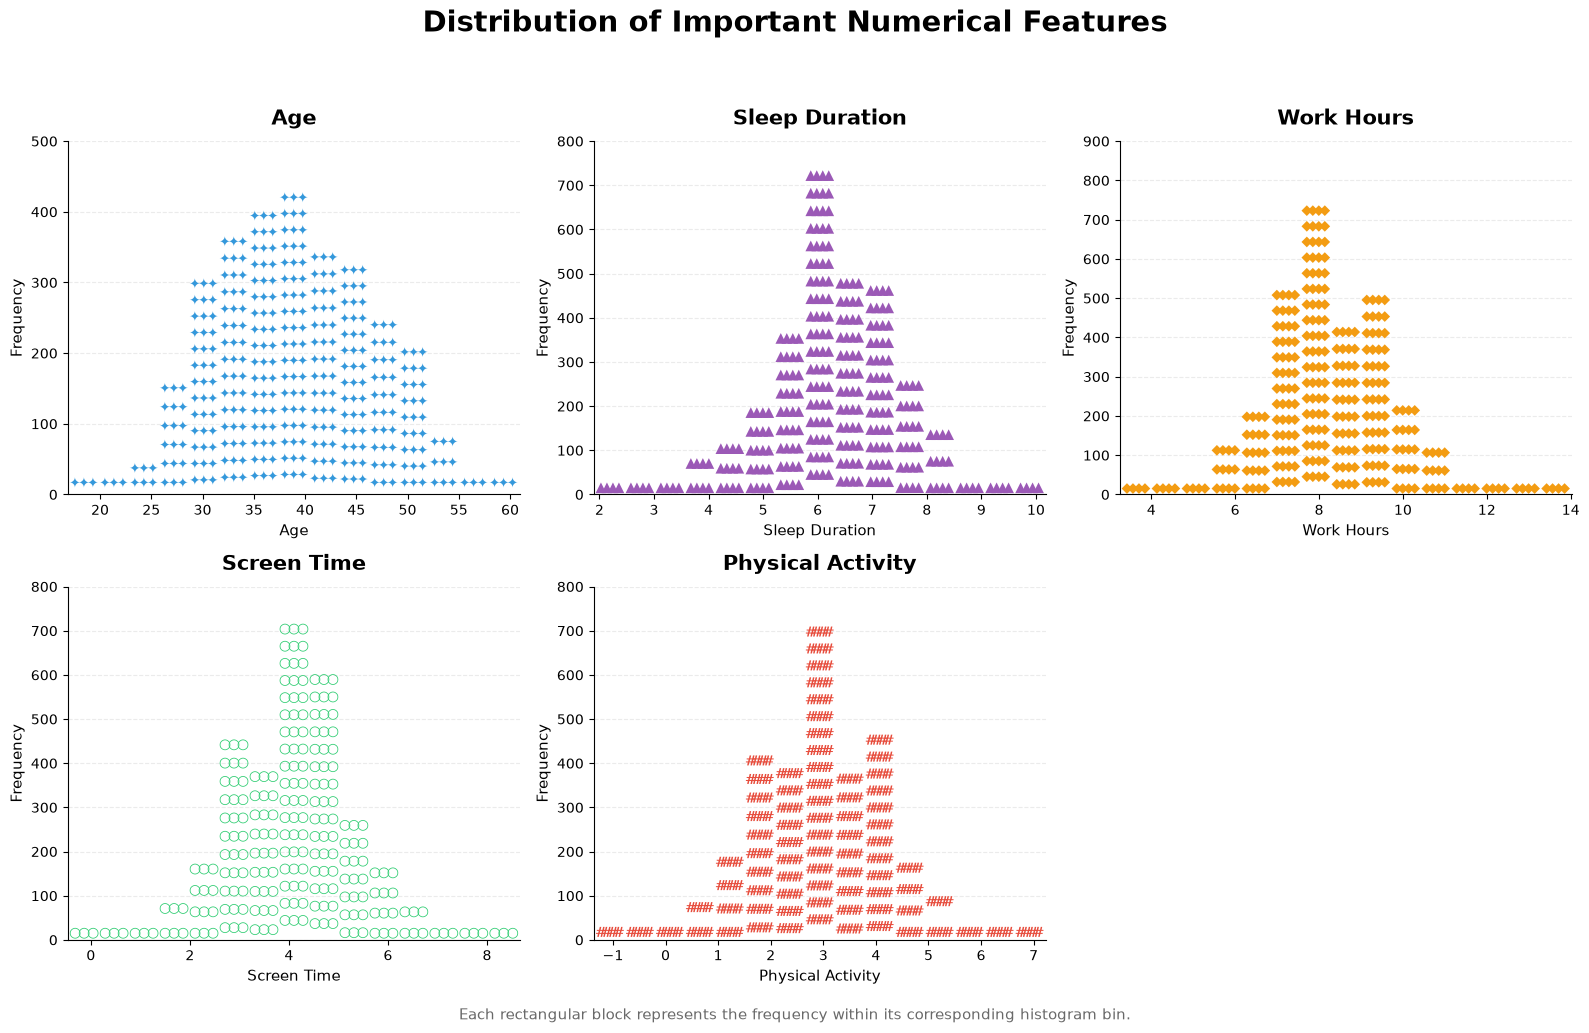

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

important_numeric = [
    "Age",
    "Sleep_Duration",
    "Work_Hours",
    "Screen_Time",
    "Physical_Activity"
]

styles = {
    "Age": {
        "sign": "✦",
        "color": "#3498DB",
        "columns": 3
    },
    "Sleep_Duration": {
        "sign": "▲",
        "color": "#9B59B6",
        "columns": 4
    },
    "Work_Hours": {
        "sign": "◆",
        "color": "#F39C12",
        "columns": 4
    },
    "Screen_Time": {
        "sign": "○",
        "color": "#2ECC71",
        "columns": 3
    },
    "Physical_Activity": {
        "sign": "#",
        "color": "#E74C3C",
        "columns": 4
    }
}

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, col in enumerate(important_numeric):

    ax = axes[i]
    values = df[col].dropna()
    style = styles[col]

    temp_fig, temp_ax = plt.subplots()

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=15,
        ax=temp_ax
    )

    y_max = temp_ax.get_ylim()[1]

    plt.close(temp_fig)

    counts, bins = np.histogram(
        values,
        bins=15
    )

    bin_width = bins[1] - bins[0]
    max_count = counts.max()

    for bin_index, count in enumerate(counts):

        if count == 0:
            continue

        left = bins[bin_index]
        right = bins[bin_index + 1]

        signs_per_row = style["columns"]

        sign_rows = max(
            1,
            int(np.round(count / max_count * 18))
        )

        x_positions = np.linspace(
            left + bin_width * 0.20,
            right - bin_width * 0.20,
            signs_per_row
        )

        bottom_position = max(
            15,
            count * 0.06
        )

        y_positions = np.linspace(
            bottom_position,
            count * 0.96,
            sign_rows
        )

        for y in y_positions:
            for x in x_positions:

                ax.text(
                    x,
                    y,
                    style["sign"],
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color=style["color"],
                    zorder=3
                )

    ax.set_xlim(
        bins[0] - bin_width * 0.05,
        bins[-1] + bin_width * 0.05
    )

    ax.set_ylim(
        0,
        y_max
    )

    y_ticks = np.arange(
        0,
        np.ceil(y_max / 100) * 100 + 1,
        100
    )

    ax.set_yticks(y_ticks)

    ax.set_yticklabels(
        [f"{int(v):,}" for v in y_ticks],
        fontsize=10
    )

    ax.set_title(
        col.replace("_", " "),
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        col.replace("_", " "),
        fontsize=11
    )

    ax.set_ylabel(
        "Frequency",
        fontsize=11
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
        zorder=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.delaxes(axes[5])

plt.suptitle(
    "Distribution of Important Numerical Features",
    fontsize=21,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.01,
    "Each rectangular block represents the frequency within "
    "its corresponding histogram bin.",
    ha="center",
    fontsize=11,
    color="dimgray"
)

plt.tight_layout(
    rect=[0, 0.03, 1, 0.98]
)

plt.show()

## EDA : Sleep Duration Distribution Across Stress Level

OVERALL SLEEP DURATION STATISTICS


,Statistic,Value
0,Count,3000.00
1,Mean,6.32
2,Median,6.30
3,Std. Deviation,1.14
4,Minimum,1.92
5,Q1,5.70
6,Q3,7.00
7,Maximum,10.16
8,Range,8.24
9,IQR,1.30


SLEEP DURATION BY STRESS LEVEL


,count,mean,median,std,min,max
Stress_Detection,,,,,,
Low,624,6.60,6.74,1.20,2.25,10.02
Medium,1258,6.32,6.30,1.11,2.40,9.63
High,1118,6.16,6.17,1.10,1.92,10.16


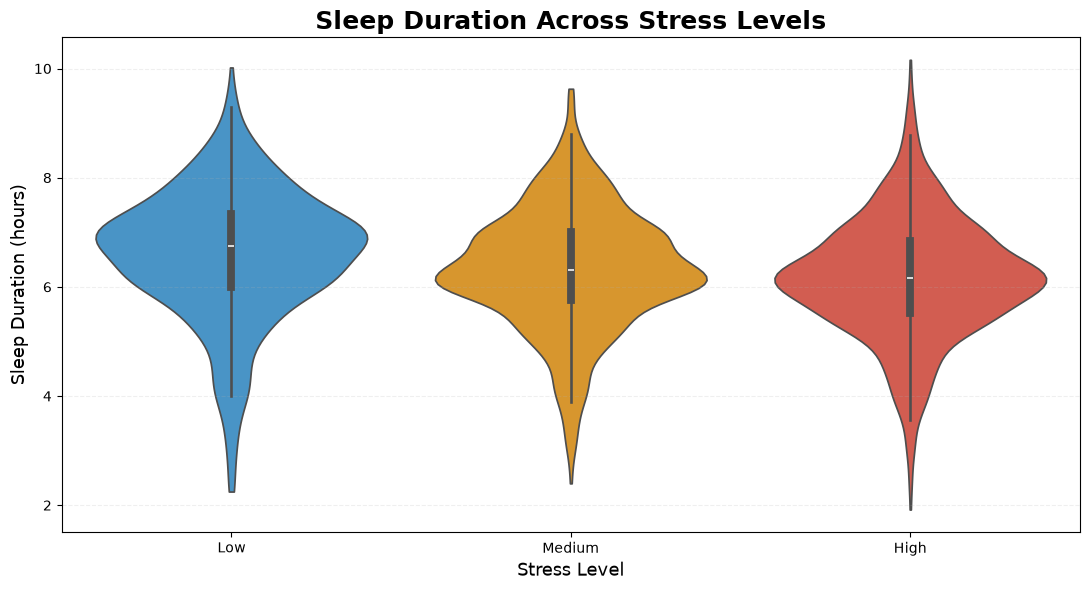

Spearman correlation: -0.164


In [82]:

sleep = df["Sleep_Duration"].dropna()

# ------------------------------------------------------------
# 1. Overall Statistics
# ------------------------------------------------------------

q1 = sleep.quantile(0.25)
q3 = sleep.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = sleep[
    (sleep < lower_bound) |
    (sleep > upper_bound)
]

sleep_stats = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Std. Deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "Range",
        "IQR",
        "Skewness",
        "Kurtosis",
        "Outliers",
        "Outlier %"
    ],
    "Value": [
        len(sleep),
        sleep.mean(),
        sleep.median(),
        sleep.std(),
        sleep.min(),
        q1,
        q3,
        sleep.max(),
        sleep.max() - sleep.min(),
        iqr,
        sleep.skew(),
        sleep.kurtosis(),
        len(outliers),
        len(outliers) / len(sleep) * 100
    ]
})

sleep_stats["Value"] = sleep_stats["Value"].round(2)

print("OVERALL SLEEP DURATION STATISTICS")
display(sleep_stats)


# ------------------------------------------------------------
# 2. Sleep Duration by Stress Level
# ------------------------------------------------------------

stress_order = ["Low", "Medium", "High"]

sleep_by_stress = (
    df.groupby("Stress_Detection")["Sleep_Duration"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .reindex(stress_order)
    .round(2)
)

print("SLEEP DURATION BY STRESS LEVEL")
display(sleep_by_stress)


# ------------------------------------------------------------
# 3. Violin Plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.violinplot(
    data=df,
    x="Stress_Detection",
    y="Sleep_Duration",
    order=stress_order,
    hue="Stress_Detection",
    palette={
        "Low": "#3498DB",
        "Medium": "#F39C12",
        "High": "#E74C3C"
    },
    inner="box",
    cut=0,
    legend=False
)

plt.title(
    "Sleep Duration Across Stress Levels",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Stress Level",
    fontsize=13
)

plt.ylabel(
    "Sleep Duration (hours)",
    fontsize=13
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Spearman Correlation
# ------------------------------------------------------------

stress_numeric = df["Stress_Detection"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

spearman_corr = df["Sleep_Duration"].corr(
    stress_numeric,
    method="spearman"
)

print(f"Spearman correlation: {spearman_corr:.3f}")

## EDA : Physical Activity and Stress Level

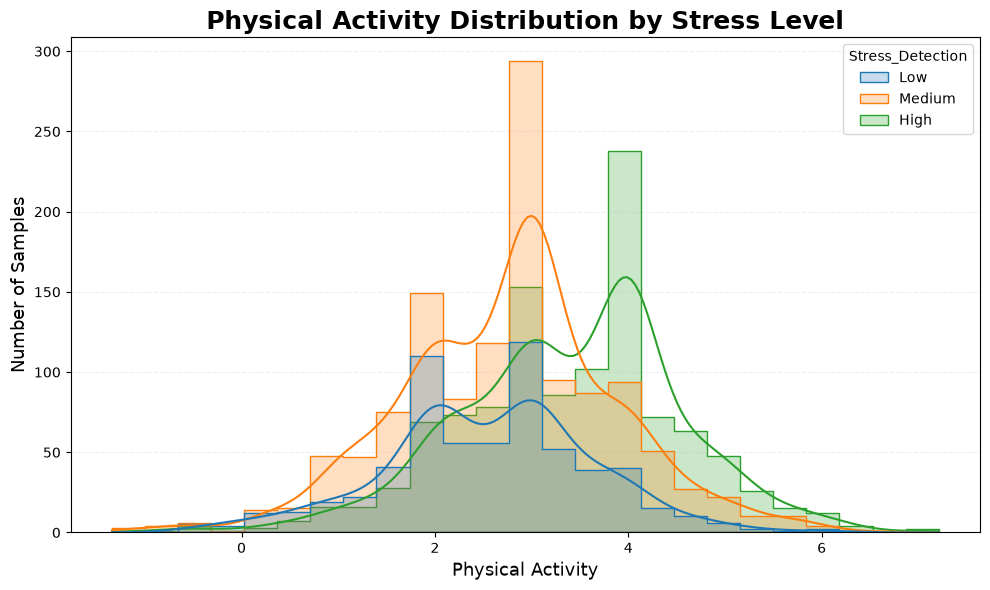

Spearman correlation = 0.302


In [83]:
# ============================================================
# EDA: Physical Activity Analysis
# ============================================================

stress_order = ["Low", "Medium", "High"]

# 2. Physical Activity Across Stress Levels
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Physical_Activity",
    hue="Stress_Detection",
    hue_order=stress_order,
    bins=25,
    kde=True,
    element="step",
    common_norm=False
)

plt.title(
    "Physical Activity Distribution by Stress Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Physical Activity", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()




# ------------------------------------------------------------
# 3. Spearman Association with Stress
# ------------------------------------------------------------

stress_numeric = df["Stress_Detection"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

spearman_corr = df["Physical_Activity"].corr(
    stress_numeric,
    method="spearman"
)

print(f"Spearman correlation = {spearman_corr:.3f}")

# EDA: Screen Time Analysis

Stress_Detection,Low,Medium,High
Screen_Time_Group,,,
≤2 hours,44.27,40.46,15.27
2–4 hours,26.41,49.49,24.10
4–6 hours,12.93,34.89,52.18
>6 hours,10.37,26.67,62.96


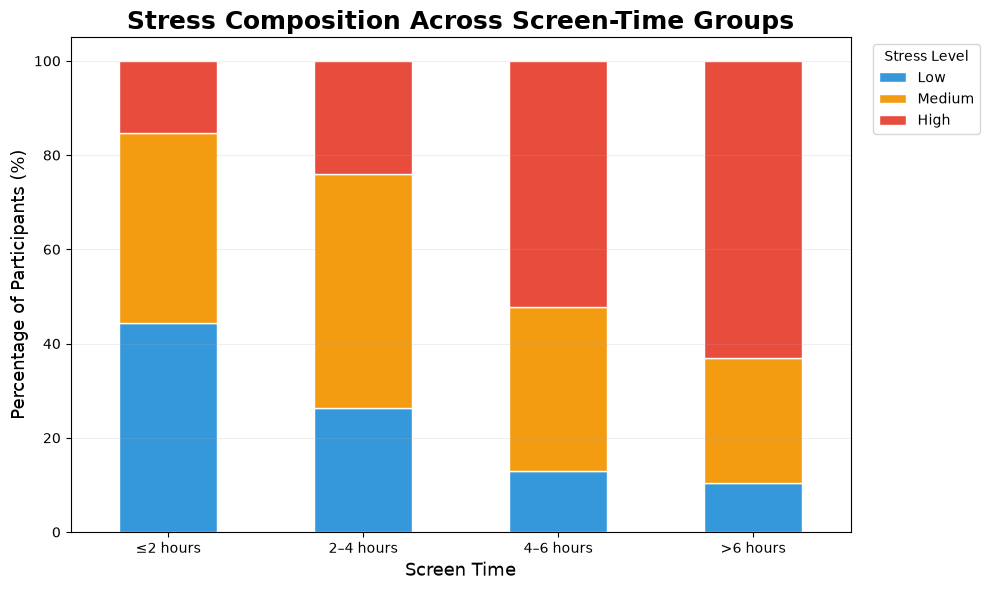

,mean,median
Stress_Detection,,
Low,3.53,3.48
Medium,3.90,4.00
High,4.55,4.77


In [34]:

# Create meaningful screen-time groups
df["Screen_Time_Group"] = pd.cut(
    df["Screen_Time"],
    bins=[-np.inf, 2, 4, 6, np.inf],
    labels=["≤2 hours", "2–4 hours", "4–6 hours", ">6 hours"]
)

stress_order = ["Low", "Medium", "High"]

# ------------------------------------------------------------
# 1. Stress distribution within screen-time groups
# ------------------------------------------------------------

screen_stress = pd.crosstab(
    df["Screen_Time_Group"],
    df["Stress_Detection"],
    normalize="index"
).reindex(columns=stress_order)

display((screen_stress * 100).round(2))


# ------------------------------------------------------------
# 2. 100% stacked bar chart
# ------------------------------------------------------------

ax = (screen_stress * 100).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#3498DB", "#F39C12", "#E74C3C"],
    edgecolor="white"
)

plt.title(
    "Stress Composition Across Screen-Time Groups",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Screen Time", fontsize=13)
plt.ylabel("Percentage of Participants (%)", fontsize=13)

plt.xticks(rotation=0)
plt.legend(
    title="Stress Level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Mean screen time by stress level
# ------------------------------------------------------------

mean_screen = (
    df.groupby("Stress_Detection")["Screen_Time"]
      .agg(["mean", "median"])
      .reindex(stress_order)
      .round(2)
)

display(mean_screen)

# EDA : Work Hours and Stress

,mean,median,std
Stress_Detection,,,
Low,7.99,8.00,1.29
Medium,8.01,8.00,1.37
High,8.66,8.66,1.27


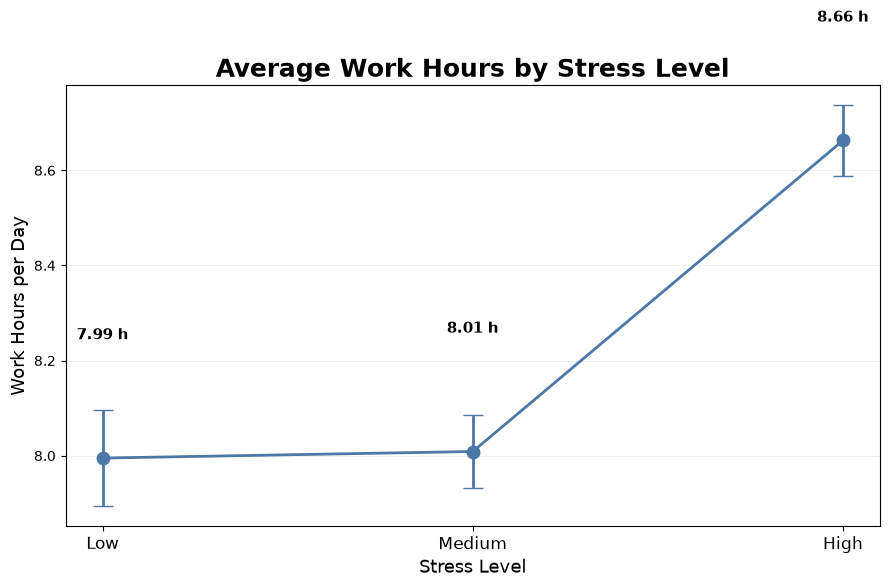

Spearman correlation = 0.223


In [36]:
# ============================================================
# EDA 15: Work Hours and Stress
# ============================================================

stress_order = ["Low", "Medium", "High"]

# ------------------------------------------------------------
# 1. Group-wise statistics
# ------------------------------------------------------------

work_summary = (
    df.groupby("Stress_Detection")["Work_Hours"]
      .agg(["mean", "median", "std"])
      .reindex(stress_order)
      .round(2)
)

display(work_summary)


# ------------------------------------------------------------
# 2. Mean Work Hours with 95% Confidence Interval
# ------------------------------------------------------------

summary = (
    df.groupby("Stress_Detection")["Work_Hours"]
      .agg(["mean", "std", "count"])
      .reindex(stress_order)
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci"] = 1.96 * summary["se"]

plt.figure(figsize=(9, 6))

x = np.arange(len(stress_order))

plt.errorbar(
    x,
    summary["mean"],
    yerr=summary["ci"],
    fmt="o-",
    capsize=7,
    linewidth=2,
    markersize=9,
    color="#4C78A8"
)

for i, value in enumerate(summary["mean"]):
    plt.text(
        i,
        value + 0.25,
        f"{value:.2f} h",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.xticks(
    x,
    stress_order,
    fontsize=12
)

plt.title(
    "Average Work Hours by Stress Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Stress Level", fontsize=13)
plt.ylabel("Work Hours per Day", fontsize=13)

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Spearman Association
# ------------------------------------------------------------

stress_numeric = df["Stress_Detection"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

spearman_corr = df["Work_Hours"].corr(
    stress_numeric,
    method="spearman"
)

print(f"Spearman correlation = {spearman_corr:.3f}")

# EDA: Caffeine Intake & Stress

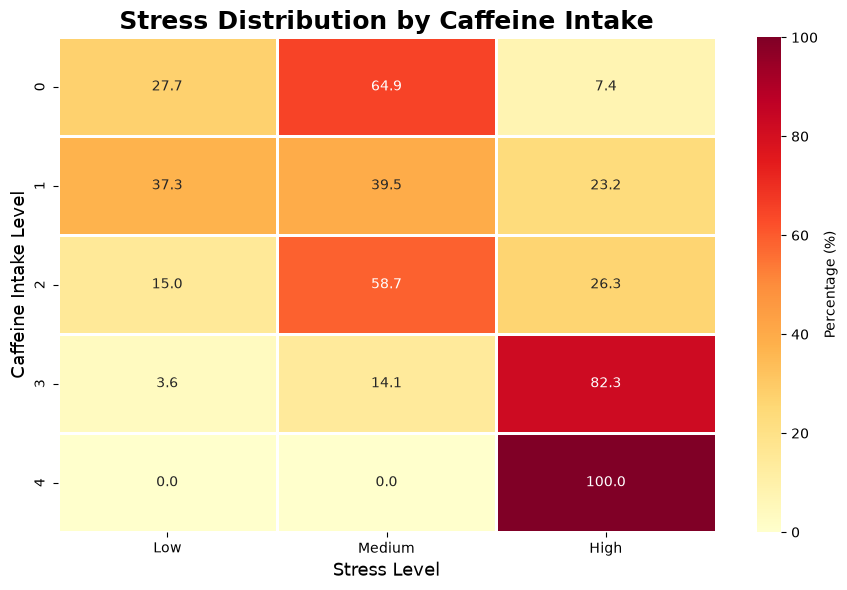

In [38]:

caffeine_stress_pct = pd.crosstab(
    df["Caffeine_Intake"],
    df["Stress_Detection"],
    normalize="index"
).reindex(columns=stress_order, fill_value=0) * 100

plt.figure(figsize=(9, 6))

sns.heatmap(
    caffeine_stress_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Percentage (%)"}
)

plt.title(
    "Stress Distribution by Caffeine Intake",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Stress Level", fontsize=13)
plt.ylabel("Caffeine Intake Level", fontsize=13)

plt.tight_layout()
plt.show()

# EDA: Work Hours vs Sleep Duration

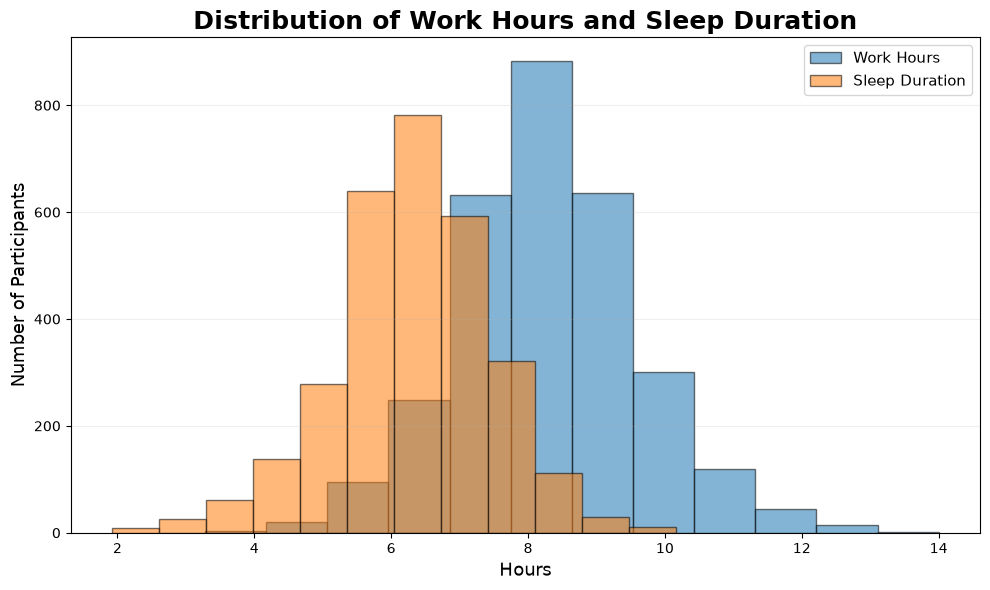

In [44]:

plt.figure(figsize=(10, 6))

# Work Hours
plt.hist(
    df["Work_Hours"].dropna(),
    bins=12,
    alpha=0.55,
    label="Work Hours",
    edgecolor="black"
)

# Sleep Duration
plt.hist(
    df["Sleep_Duration"].dropna(),
    bins=12,
    alpha=0.55,
    label="Sleep Duration",
    edgecolor="black"
)

plt.title(
    "Distribution of Work Hours and Sleep Duration",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Hours",
    fontsize=13
)

plt.ylabel(
    "Number of Participants",
    fontsize=13
)

plt.legend(
    fontsize=11
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

## EDA: PCA Visualization of Important Features

PCA STATISTICAL SUMMARY
---------------------------------------------
Number of observations : 3,000
Number of features     : 5
PC1 variance           : 31.51%
PC2 variance           : 22.73%
Total variance         : 54.24%

Explained Variance Ratio:
PC1: 31.5057%
PC2: 22.7317%

PCA Eigenvalues:
PC1: 1.5758
PC2: 1.1370

PCA Component Loadings:


,PC1,PC2
Age,0.4948,-0.0062
Sleep_Duration,-0.1131,0.7680
Work_Hours,0.3629,0.6161
Screen_Time,0.5783,-0.1029
Physical_Activity,0.5256,-0.1410


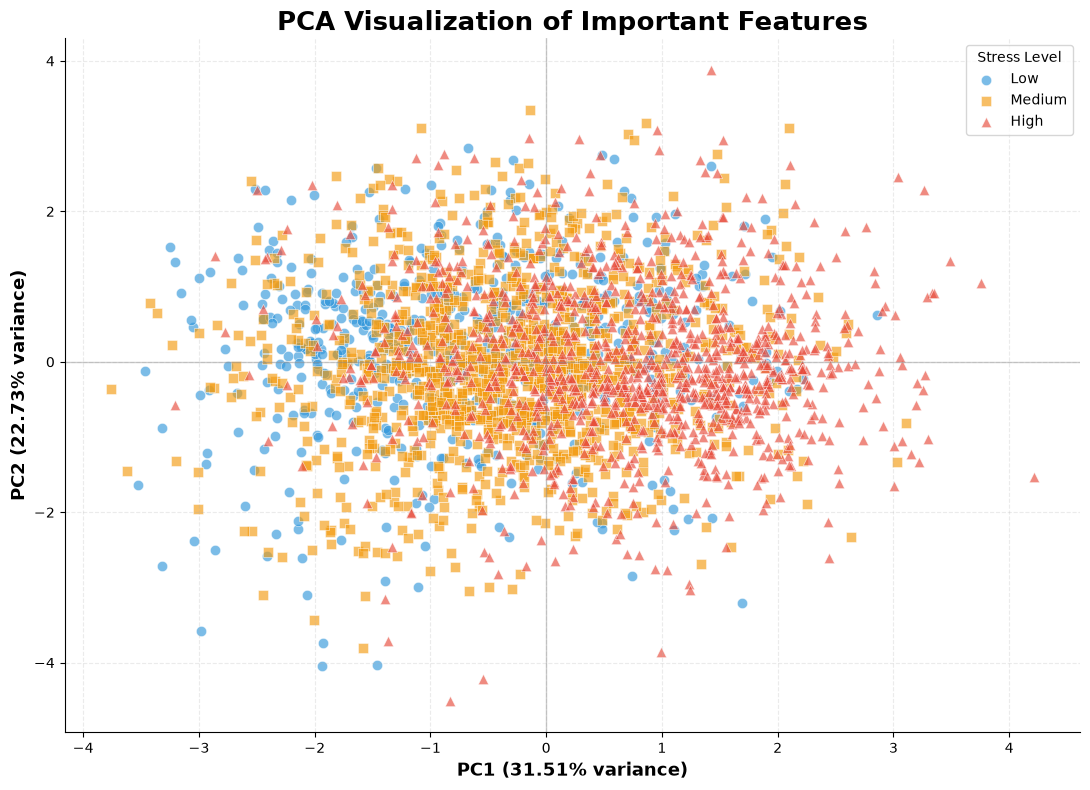

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    "Age",
    "Sleep_Duration",
    "Work_Hours",
    "Screen_Time",
    "Physical_Activity"
]

pca_data = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=pca_data.index
)

pca_df["Stress_Detection"] = df.loc[
    pca_data.index,
    "Stress_Detection"
].values

print("PCA STATISTICAL SUMMARY")
print("-" * 45)
print(f"Number of observations : {len(pca_data):,}")
print(f"Number of features     : {len(features)}")
print(f"PC1 variance           : {variance[0]:.2f}%")
print(f"PC2 variance           : {variance[1]:.2f}%")
print(f"Total variance         : {variance.sum():.2f}%")
print()

print("Explained Variance Ratio:")
for i, value in enumerate(variance, 1):
    print(f"PC{i}: {value:.4f}%")

print()
print("PCA Eigenvalues:")
for i, value in enumerate(pca.explained_variance_, 1):
    print(f"PC{i}: {value:.4f}")

print()
print("PCA Component Loadings:")
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1", "PC2"]
)

display(loadings.round(4))

# Visualization

fig, ax = plt.subplots(figsize=(11, 8))

styles = {
    "Low": {"marker": "o", "color": "#3498DB"},
    "Medium": {"marker": "s", "color": "#F39C12"},
    "High": {"marker": "^", "color": "#E74C3C"}
}

for level in ["Low", "Medium", "High"]:

    subset = pca_df[
        pca_df["Stress_Detection"] == level
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        alpha=0.65,
        marker=styles[level]["marker"],
        color=styles[level]["color"],
        edgecolors="white",
        linewidths=0.5,
        label=level
    )

ax.axhline(0, color="gray", linewidth=1, alpha=0.4)
ax.axvline(0, color="gray", linewidth=1, alpha=0.4)

ax.set_xlabel(
    f"PC1 ({variance[0]:.2f}% variance)",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    f"PC2 ({variance[1]:.2f}% variance)",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "PCA Visualization of Important Features",
    fontsize=19,
    fontweight="bold"
)

ax.legend(title="Stress Level")

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# EDA: K-Means Cluster Analysis

K-MEANS STATISTICAL SUMMARY
---------------------------------------------
Number of clusters : 3
Inertia             : 10514.59
Silhouette Score    : 0.1695

Cluster Distribution:
Cluster 0: 828 samples (27.60%)
Cluster 1: 1,082 samples (36.07%)
Cluster 2: 1,090 samples (36.33%)


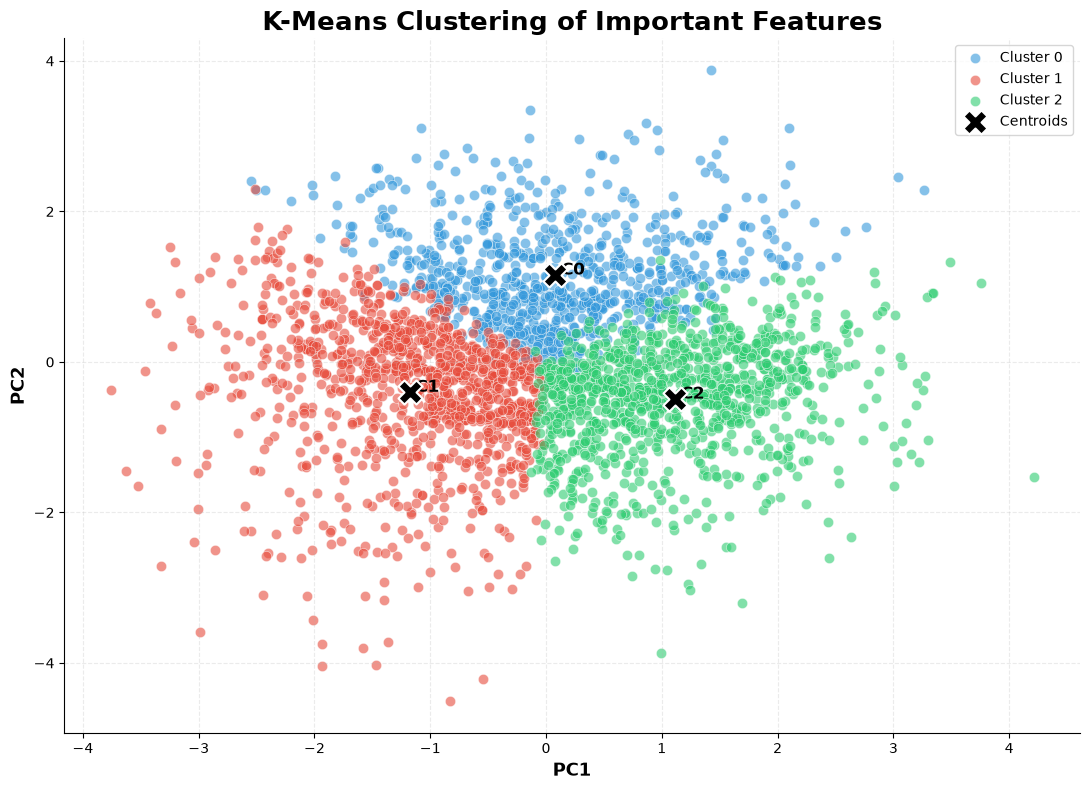

In [93]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

pca_df["Cluster"] = cluster_labels

centers = pca.transform(
    kmeans.cluster_centers_
)

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

inertia = kmeans.inertia_

cluster_counts = (
    pca_df["Cluster"]
    .value_counts()
    .sort_index()
)

print("K-MEANS STATISTICAL SUMMARY")
print("-" * 45)
print(f"Number of clusters : 3")
print(f"Inertia             : {inertia:.2f}")
print(f"Silhouette Score    : {silhouette:.4f}")
print()

print("Cluster Distribution:")
for cluster, count in cluster_counts.items():

    percentage = (
        count / len(pca_df)
    ) * 100

    print(
        f"Cluster {cluster}: "
        f"{count:,} samples "
        f"({percentage:.2f}%)"
    )

# Visualization

fig, ax = plt.subplots(figsize=(11, 8))

cluster_colors = [
    "#3498DB",
    "#E74C3C",
    "#2ECC71"
]

for cluster in range(3):

    subset = pca_df[
        pca_df["Cluster"] == cluster
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        alpha=0.60,
        color=cluster_colors[cluster],
        edgecolors="white",
        linewidths=0.5,
        label=f"Cluster {cluster}"
    )

ax.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    marker="X",
    color="black",
    edgecolors="white",
    linewidths=1.5,
    label="Centroids",
    zorder=5
)

for i, center in enumerate(centers):

    ax.text(
        center[0],
        center[1],
        f" C{i}",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xlabel(
    "PC1",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "PC2",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "K-Means Clustering of Important Features",
    fontsize=19,
    fontweight="bold"
)

ax.legend()

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# EDA : Comparison of Clusters with Actual Labels

CLUSTER VS ACTUAL LABELS
---------------------------------------------


Stress_Detection,Low,Medium,High
Cluster,,,
0,186,347,295
1,338,575,169
2,100,336,654


CLUSTER PERCENTAGES


Stress_Detection,Low,Medium,High
Cluster,,,
0,22.46,41.91,35.63
1,31.24,53.14,15.62
2,9.17,30.83,60.00



CLUSTER AGREEMENT STATISTICS
---------------------------------------------
Adjusted Rand Index (ARI) : 0.0857
Normalized Mutual Info    : 0.0787


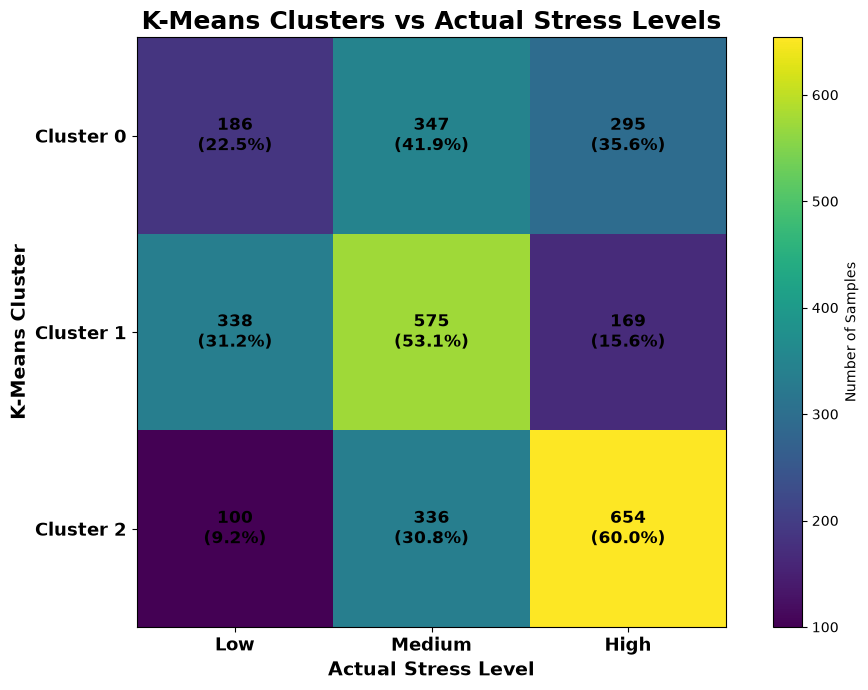

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

comparison = pd.crosstab(
    pca_df["Cluster"],
    pca_df["Stress_Detection"]
)

comparison = comparison.reindex(
    columns=["Low", "Medium", "High"],
    fill_value=0
)

print("CLUSTER VS ACTUAL LABELS")
print("-" * 45)
display(comparison)

percentages = (
    comparison.div(
        comparison.sum(axis=1),
        axis=0
    ) * 100
)

print("CLUSTER PERCENTAGES")
display(percentages.round(2))

# Cluster-label agreement metrics

label_encoder = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

actual_numeric = pca_df[
    "Stress_Detection"
].map(label_encoder)

ari = adjusted_rand_score(
    actual_numeric,
    pca_df["Cluster"]
)

nmi = normalized_mutual_info_score(
    actual_numeric,
    pca_df["Cluster"]
)

print()
print("CLUSTER AGREEMENT STATISTICS")
print("-" * 45)
print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalized Mutual Info    : {nmi:.4f}")

# Visualization

fig, ax = plt.subplots(figsize=(10, 7))

matrix = comparison.values

im = ax.imshow(matrix)

ax.set_xticks(np.arange(3))
ax.set_xticklabels(
    ["Low", "Medium", "High"],
    fontsize=13,
    fontweight="bold"
)

ax.set_yticks(np.arange(3))
ax.set_yticklabels(
    ["Cluster 0", "Cluster 1", "Cluster 2"],
    fontsize=13,
    fontweight="bold"
)

for i in range(3):

    for j in range(3):

        ax.text(
            j,
            i,
            f"{matrix[i, j]:,}\n"
            f"({percentages.iloc[i, j]:.1f}%)",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

ax.set_xlabel(
    "Actual Stress Level",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "K-Means Cluster",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "K-Means Clusters vs Actual Stress Levels",
    fontsize=18,
    fontweight="bold"
)

cbar = plt.colorbar(im, ax=ax)

cbar.set_label(
    "Number of Samples"
)

plt.tight_layout()
plt.show()